# Phase synchrony analysis

Phase synchrony analysis is a central concept in analysis of brain oscillations. In this tutorial we will first introduce some key metrics: 

1. Complex phase locking value (cPLV)
    - Phase locking value (PLV)
    - Imaginary phase locking value (iPLV)
2. Weighted phase lag index (wPLI)

After we have got familiar with these key phase synchrony metrics, we will estimate them in simulated data and compare them to each other to extend our knowledge a bit further:

3. PLV vs. iPLV vs. wPLI 

## 1. Complex Phase Locking Value (cPLV) analysis
We start by importing the needed libraries for the analysis.

In [1]:
import crosspy
import numpy as np
import matplotlib.pyplot as plt

Afterwards we load the <span style="color:#85C1E9">filtered_node_timeseries</span> from *data_preprocessing_filtering* tutorial for upcoming cPLV analysis in this section of the tutorial.

In [2]:
filtered_node_timeseries = np.load('demo_files/filtered_node_timeseries.npy')

Then we compute cPLVs between all nodes of the filtered data using crosspy's <span style="color:#F9E79F">cplv</span> method. Setting the diagonal to zero, since the cPLV for the node itself is zero. The <span style="color:#F9E79F">cplv</span> method can be studied further in more detail in the *synchrony.py* file in the crosspy package.

In [3]:
phase_synchrony = crosspy.observables.connectivity.synchrony.compute_cplv(filtered_node_timeseries)

Next we will construct a plotting method, so that we can visualize both PLV and iPLV values between the nodes as a heat map.

In [4]:
def plot_plv_or_iplv(synchrony, n_nodes, metric_label):
    
    #plotting heat map
    plt.figure(figsize=(5, 4))
    plt.pcolormesh(synchrony, cmap='viridis')

    #adding colorbar
    colorbar = plt.colorbar()
    colorbar.set_label(f'{metric_label}')

    #adding labels
    plt.xticks(ticks=np.arange(0.5, n_nodes + 0.5), labels=np.arange(1, n_nodes + 1))
    plt.yticks(ticks=np.arange(0.5, n_nodes + 0.5), labels=np.arange(1, n_nodes + 1))

    #adding gridlines
    plt.grid(True, linestyle='--', color='gray', linewidth=0.5)

    #adding title and labels
    plt.title(f'{metric_label} between nodes')
    plt.xlabel('Node')
    plt.ylabel('Node')

    plt.tight_layout()
    plt.show()

The PLV values describes the phase differences between two nodes averaged across time. The higher PLV value, the higher functional connectivity between the nodes.

We obtain the PLV values between the node pairs, by taking the absolute values of cPLV. We can then call the the plotting method above to plot the PLV values between the nodes as a heat map.

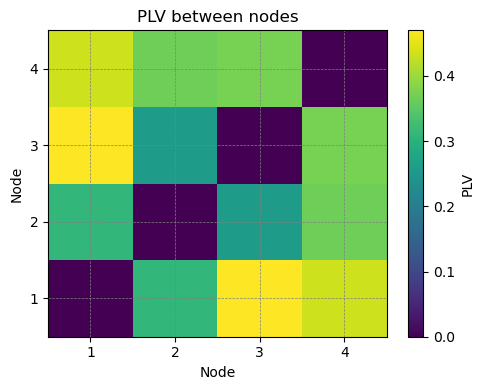

In [5]:
plv = np.abs(phase_synchrony)
np.fill_diagonal(plv, 0.0)
n_nodes = phase_synchrony.shape[0]

plot_plv_or_iplv(plv, n_nodes, 'PLV')

In the PLV heat map above, we see that e.g. nodes 1 and 3 show high functional connectivity between the nodes while nodes 2 and 3 shows quite low functional connectivity. Note that the functional connectivity between the node itself is naturally none.

Beside the PLV values, we can also derive the iPLV values from the cPLV values. Compared to PLV, iPLV effectively discards all zero-lag interactions, most of which are caused by instantaneous mixing. (*Palva 2018 NeuroImage)*

We obtain the iPLV values between the node pairs, by taking the absolute values of the imaginary part of cPLV. We can then call again the same plotting method as for PLV to plot the iPLV values between the nodes as a heat map.

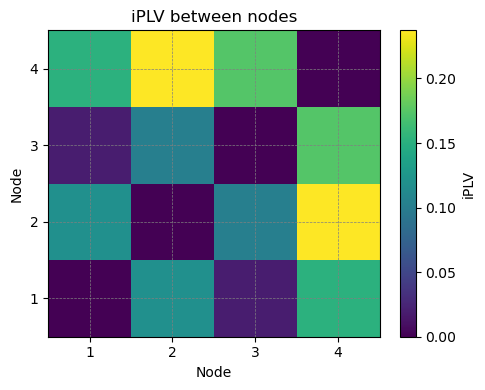

In [6]:
iplv = np.abs(np.imag(phase_synchrony))
n_nodes = phase_synchrony.shape[0]

plot_plv_or_iplv(iplv, n_nodes, 'iPLV')

Despite the similar analogy of the iPLV heatmap as for the PLV heatmap, we can notice some significant differences in the iPLV values vs. PLV values. For example nodes 1 and 3 show a low iPLV value between the nodes whereas PLV for same node pair is high. Let's return further in more detail to PLV vs. iPLV in section *3. PLV vs. iPLV vs. wPLI* section in this tutorial.

## 2. Weighted phase lag index (wPLI)

Once again we start by importing needed libraries.

In [7]:
import crosspy
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

Afterwards we load the <span style="color:#85C1E9">filtered_node_timeseries</span> from *data_preprocessing_filtering* tutorial for upcoming wPLI analysis in this section of the tutorial.

In [8]:
filtered_node_timeseries = np.load('demo_files/filtered_node_timeseries.npy')

The <span style="color:#F9E79F">wPLI</span> method takes a filtered node timeseries as an input. Additionally, one can set the method to:

- take a second node timeseries as an input (<span style="color:#85C1E9">y</span>)
- compute debiased wPLI (<span style="color:#85C1E9">debias</span>)
- compute surrogate value from time-shifted data <span style="color:#85C1E9">surr</span>
- set the diagonal to zero <span style="color:#85C1E9">zero_daig</span>
- normalize the input data <span style="color:#85C1E9">is_normed</span>
- replace NaN values in the computed values with 0 <span style="color:#85C1E9">correct_nan</span>

The <span style="color:#F9E79F">wpli</span> method can be studied further in more detail in the *synchrony.py* file in the crosspy package.

Here we will demonstrate how to calculate the wPLI values of a node timeseries that is not normalized (<span style="color:#85C1E9">filtered_node_timeseries</span>), and replacing NaN values in the computed values to 0. 

In [9]:
wPLI = crosspy.observables.connectivity.synchrony.compute_wpli(filtered_node_timeseries)

To visualize the obtained wPLI values between the nodes, we can plot a heat map. 

In [10]:
def plot_wpli(wpli):
    n_nodes = wpli.shape[0]

    # custom red-blue colormap
    cmap = plt.get_cmap('coolwarm')
    norm = TwoSlopeNorm(vmin=wpli.min(), vcenter=0, vmax=wpli.max())
    
    #plotting heat map
    plt.figure(figsize=(5, 4))
    plt.pcolormesh(wpli, cmap=cmap, norm=norm)

    #adding colorbar
    colorbar = plt.colorbar()
    colorbar.set_label('wPLI')

    #adding labels
    plt.xticks(ticks=np.arange(0.5, n_nodes + 0.5), labels=np.arange(1, n_nodes + 1))
    plt.yticks(ticks=np.arange(0.5, n_nodes + 0.5), labels=np.arange(1, n_nodes + 1))

    #adding gridlines
    plt.grid(True, linestyle='--', color='gray', linewidth=0.5)

    #adding title and labels
    plt.title('wPLI between nodes')
    plt.xlabel('Node')
    plt.ylabel('Node')

    plt.tight_layout()
    plt.show()

Phase locking value (PLV) is widely used, but it is sensitive to volume conduction. To overcome that, phase lag index (PLI) has been applied to evaluate the phase synchronization degree between different signals. Furthermore, wPLI improves the discontinuity of PLI indicators. (*Ma 2022 CNS Neurosci. Ther.*)

By calling the plotting method, we can study the wPLI values between different pairs of nodes.

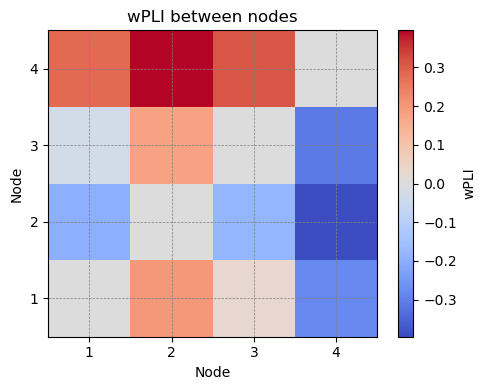

In [11]:
plot_wpli(wPLI)

In the wPLI heatmap we can see negative and positve values. Negatives wPLI values indicates that the first node is leading and the other node is lagging, and when positive wPLI values vice verca. A good demonstration of this is when one consider node 2 as the first node (x-axis) and node 4 as the second node (y-axis), then wPLI value is positive on the high end. When node 4 is considered as first node and 2 as the second node, then the wPLI value is negative on the low end. From this one can conclude that node 2 is leading and node 4 is lagging. Based on the magnitude of the value one can further on conclude that synchrony between the nodes 2 and 4 are realtively high.

## 3. PLV vs. iPLV vs. wPLI

After we familiarized ourselves with the PLV, iPLV, and wPLI phase synchronization metrics in sections 1 and 2 in this tutorial, let's look a bit further what we can learn by anlyzing them all together. We will begin with to construct two signals with specfic properties and mix them. Afterwards we are going to analyze two different cases for the two signals:

* 3.1. Phase mixing parameter affect on synchrony
* 3.2. Mean phase difference affect on synchrony

As usual we start off by importing necessary libraries.

In [12]:
import crosspy
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

Deviating a bit from the earlier part of the tutorial, we will not utilize node timeseries genereated by [Palva lab's Hierarchial Kuramoto model](https://version.helsinki.fi/palvalabgroup/hierarchical_kuramoto), but instead we will tailor signals with specific properties. The reason for this approach is to assure a clearer demonstration of the differences between PLV vs. iPLV vs. wPLI.

Some of the key differences between PLV vs. iPLV vs. wPLI can be observed when signals are mixed with eachother. Taking into account mixing of signals is important since it is the reality in brain recordings, e.g. electroencephalogram (EEG). A brain recording sensor will most likely record some part of a signal that is intended to be recorded by a nearby other sensor.

In the <span style="color:#F9E79F">mix_two_filtered_signals</span> method, we will i) construct two signals and ii) mixing them as described by *Palva 2018 Neuroimage*

In [13]:
def mix_two_filtered_signals(c_A, c_theta, m, phase_shift, N=500000):
    '''
    Constructing two filtered mixed signals as described by Palva 2018 NeuroImage.
    INPUT:
        c_A:            Amplitude mixing parameter
        c_theta:        Phase mixing parameter
        m:              Signals inter-mixing parameter
        phase_shift:    Controlling mean phase difference across x and y signals
        N:              Number of samples
    OUTPUT:
        Numpy array of signals x and y
    '''
    
    #helper method to filter the timeseries
    def _filter_wrapper(timeseries):
        return crosspy.preprocessing.signal.filter_data(timeseries.reshape(1, *timeseries.shape), sfreq=250, frequency=10, omega=5.0, n_jobs=1).squeeze()
    
    #generating random values for further manipulation
    noise_timeseries = np.random.normal(size=(4, N))

    #generating amplitudes for signal x and signal y
    A_x = np.abs(_filter_wrapper(noise_timeseries[0] + c_A*noise_timeseries[1]))
    A_y = np.abs(_filter_wrapper(noise_timeseries[1] + c_A*noise_timeseries[0]))

    #generating phases for signal x and signal y
    phase_x = np.angle(_filter_wrapper(noise_timeseries[2] + c_theta*noise_timeseries[3]))
    phase_y = np.angle(_filter_wrapper(noise_timeseries[3] + c_theta*noise_timeseries[2]))

    #assembling complex-valued mixed time series x and y
    x = A_x*np.exp(1j*phase_x) + m*A_y * np.exp(1j*(phase_y + phase_shift))
    y = A_y*np.exp(1j*(phase_y + phase_shift)) + m*A_x * np.exp(1j*phase_x)
    
    return np.array([x, y])

### 3.1. Phase mixing parameter affect on synchrony

Let's define different phase mixing parameters <span style="color:#85C1E9">c_theta</span> and different signals inter-mixing parameters <span style="color:#85C1E9">m</span>. Additionally we set the amplitude mixing parameter <span style="color:#85C1E9">c_A</span> and phase-shift <span style="color:#85C1E9">phase_shift</span> both to one.

In [14]:
c_A_list = [1]
c_theta_list = [i/100 for i in range(101)]
m_list = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6]
phase_shift_list= [1]

We create a <span style="color:#F9E79F">plv_iplv_wpli</span> method that calculates the PLV, iPLV, and wPLI values for one of the below options:

* different <span style="color:#85C1E9">c_theta</span> and same <span style="color:#85C1E9">phase_shift</span>
* different <span style="color:#85C1E9">phase_shift</span> and same <span style="color:#85C1E9">c_theta</span>

When we in the previous block set <span style="color:#85C1E9">c_theta</span>  as a list and <span style="color:#85C1E9">phase_shift</span> to a single value, the <span style="color:#F9E79F">plv_iplv_wpli</span> method will return PLV, iPLV, and wPLI values for different <span style="color:#85C1E9">c_theta</span> and same <span style="color:#85C1E9">phase_shift</span>. The vice verca option we will return to in section 3.2 in this tutorial.

In [15]:
def plv_iplv_wpli(c_A_list, c_theta_list, m_list, phase_shift_list):
    '''
    Calculating plvs, iplvs, and wplis for either i) different c_thetas and same phase_shift 
    or ii) different phase_shifts and same c_theta.
    INPUT:
        c_A_list:            Amplitude mixing parameter list
        c_theta_list:        Phase mixing parameter list
        m_list:              Signals inter-mixing parameter list
        phase_shift_list:    Controlling mean phase difference list across signals x and y
    OUTPUT:
        plvs, iplvs, wplis
    '''

    cplv_list = np.empty((0, 2, 2), dtype=np.complex128)
    wpli_list = np.empty((0, 2, 2), dtype=float)

    plv_list = np.empty((0, 2, 2), dtype=float)
    iplv_list = np.empty((0, 2, 2), dtype=float)
    
    #calculating cplvs and wplis
    for m in m_list:
        #if studying plv, iplv, and wpli for different c_thetas and same phase_shift 
        if len(c_theta_list) > len(phase_shift_list):
            for c_theta in c_theta_list:
                signals_mixed = mix_two_filtered_signals(c_A_list[0], c_theta, m, phase_shift_list[0])

                cplv = crosspy.observables.connectivity.synchrony.compute_cplv(signals_mixed, zero_diag=True)
                cplv_list = np.append(cplv_list, [cplv], axis=0)
                
                wpli_vals = np.abs(crosspy.observables.connectivity.synchrony.compute_wpli(signals_mixed))
                np.fill_diagonal(wpli_vals, 0.0)
                wpli_list = np.append(wpli_list, [wpli_vals], axis=0)
                
                plv_vals = np.abs(cplv)
                np.fill_diagonal(plv_vals, 0.0)
                plv_list = np.append(plv_list, [plv_vals], axis=0)

                iplv_vals = np.abs(np.imag(cplv))
                np.fill_diagonal(iplv_vals, 0.0)
                iplv_list = np.append(iplv_list, [iplv_vals], axis=0)

        #if studying plv, iplv, and wpli for different phase_shifts and same c_theta 
        if len(c_theta_list) < len(phase_shift_list):
            for phase_shift in phase_shift_list:
                signals_mixed = mix_two_filtered_signals(c_A_list[0], c_theta_list[0], m, phase_shift)

                cplv = crosspy.observables.connectivity.synchrony.compute_cplv(signals_mixed, zero_diag=True)
                cplv_list = np.append(cplv_list, [cplv], axis=0)
                
                wpli_vals = np.abs(crosspy.observables.connectivity.synchrony.compute_wpli(signals_mixed))
                np.fill_diagonal(wpli_vals, 0.0)
                wpli_list = np.append(wpli_list, [wpli_vals], axis=0)
                
                plv_vals = np.abs(cplv)
                np.fill_diagonal(plv_vals, 0.0)
                plv_list = np.append(plv_list, [plv_vals], axis=0)

                iplv_vals = np.abs(np.imag(cplv))
                np.fill_diagonal(iplv_vals, 0.0)
                iplv_list = np.append(iplv_list, [iplv_vals], axis=0)
        
    return plv_list, iplv_list, wpli_list

In order to study the calcualted PLV, iPLV, and wPLI values we create a plotting method. Note that we are not using plt.show() at the end of the method as for other plotting methods. This is to enable saving of plots prior to showing them. Showing the plots will essentially remove the plots.

In [16]:
def plot_selected_synchrony(synchrony: np.ndarray, m_list: list, x_values: list, x_label: str, y_label: str):
    '''
    Plotting plvs, iplvs, and wplis as a function of c_theta or phase_shift
    INPUT:
        synchrony:      List of numpy arrays, where each array contains a 2x2 matrix i.e. plvs, iplvs, or wplis
        m_list:         Signals inter-mixing parameter list    
        x_values:       List of x_values i.e. either c_theta_list or phase_shift_list
        x_label:        Label of x_axis i.e. c_theta or phase_shift
        y_label:        Label of y-axis i.e. PLV, iPLV, or wPLI
    OUTPUT:
        plvs / iplvs / wpli plot
    '''
    num_m_values = len(m_list)

    #plotting loop for m_list values
    for i in range(num_m_values):
        start_idx = i * len(x_values)
        end_idx = (i + 1) * len(x_values)
        m_values_subset = synchrony[start_idx:end_idx, :, :]
        m_values_subset = abs(m_values_subset[:, 1, 0])
        plt.plot(x_values, m_values_subset, label=f'm={m_list[i]}')

    plt.xlabel(x_label)
    plt.ylabel(f'{y_label}')
    plt.title(f'{y_label} as a function of {x_label}')
    plt.legend()

In the <span style="color:#F9E79F">mix_two_filtered_signals</span> method, we started of by inducing random values in the <span style="color:#85C1E9">noise_timeseries</span>. These random values will leave a legacy as noisy curves when plotting PLV, iPLV, and wPLI with the <span style="color:#F9E79F">plv_iplv_wpli</span> method directly. To handle the noisy curves, we will here create a method that calculate the PLV, iPLV, and wPLI means of several individual values.

In [17]:
def mean_plv_iplv_wpli(c_A_list, c_theta_list, m_list, phase_shift_list, iterations):
    #lists for storing synchrony results
    plvs_list = []
    iplvs_list = []
    wplis_list = []

    #calling plv_iplv_wpli method for a desired times of iterations and storing synchrony values 
    for _ in range(iterations):
        plvs, iplvs, wplis = plv_iplv_wpli(c_A_list, c_theta_list, m_list, phase_shift_list)
        plvs_list.append(plvs)
        iplvs_list.append(iplvs)
        wplis_list.append(wplis)

    #converting synchrony lists to numpy arrays for easy manipulation
    plvs_array = np.array(plvs_list)
    iplvs_array = np.array(iplvs_list)
    wplis_array = np.array(wplis_list)

    #calculating mean of synchrony metrics
    mean_plvs = np.mean(plvs_array, axis=0)
    mean_iplvs = np.mean(iplvs_array, axis=0)
    mean_wplis = np.mean(wplis_array, axis=0)

    return mean_plvs, mean_iplvs, mean_wplis

Now we are all set to look how PLV, iPLV, and wPLI behave for different phase mixing parameters <span style="color:#85C1E9">c_theta</span> and signals inter-mixing parameters <span style="color:#85C1E9">m</span>. Here we will call the <span style="color:#F9E79F">plv_iplv_wpli</span> method 10 times (<span style="color:#85C1E9">iterations</span>) in order to calculate the means of the PLV, iPLV, and wPLI values. 

The processing time is on the order of approx. 1.5h (Option 1), so now you have time for some other activities. If you are too eager to wait for the plots and do not mind the noisy curves, you can skip the next code block and go to the following code block (Option 2) to see how the synchrony results looks like (processing time approx. 10min). If you are even more eager, you can go to the third code block (Option 3) below and just open the plots that was generated with 10 <span style="color:#85C1E9">iterations</span>. 

In [18]:
#OPTION 1: Less noisy synchrony curves, processing time approx. 1.5h

iterations = 10
mean_plvs, mean_iplvs, mean_wplis = mean_plv_iplv_wpli(c_A_list, c_theta_list, m_list, phase_shift_list, iterations)

KeyboardInterrupt: 

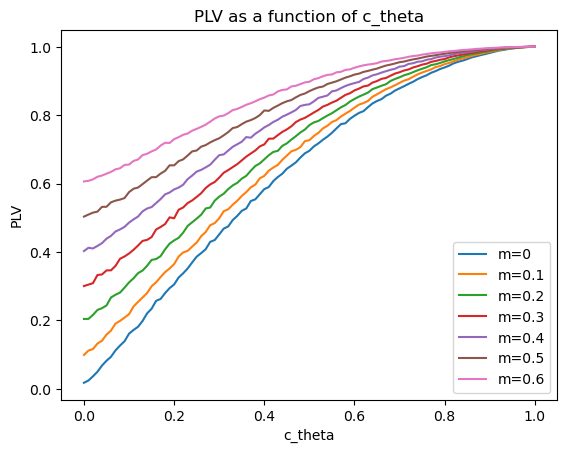

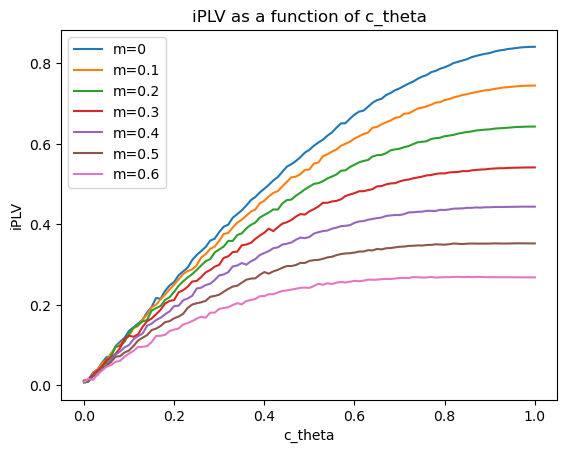

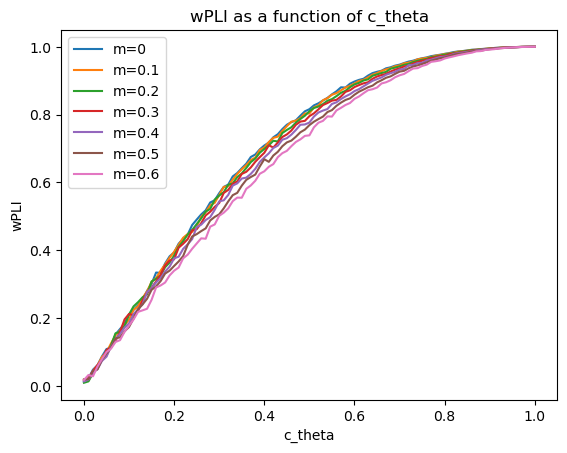

In [34]:
#plottting less noisy synchrony curves. saving plots. plt.show() needed since plotting method lacks it
plot_selected_synchrony(mean_plvs, m_list, c_theta_list, 'c_theta', 'PLV')
plt.savefig('demo_files/c_theta_vs_plv.png')
plt.show()
plot_selected_synchrony(mean_iplvs, m_list, c_theta_list, 'c_theta','iPLV')
plt.savefig('demo_files/c_theta_vs_iplv.png')
plt.show()
plot_selected_synchrony(mean_wplis, m_list, c_theta_list,'c_theta', 'wPLI')
plt.savefig('demo_files/c_theta_vs_wpli.png')
plt.show()

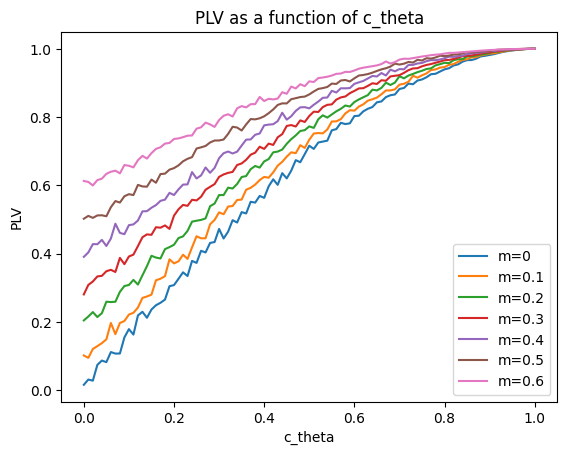

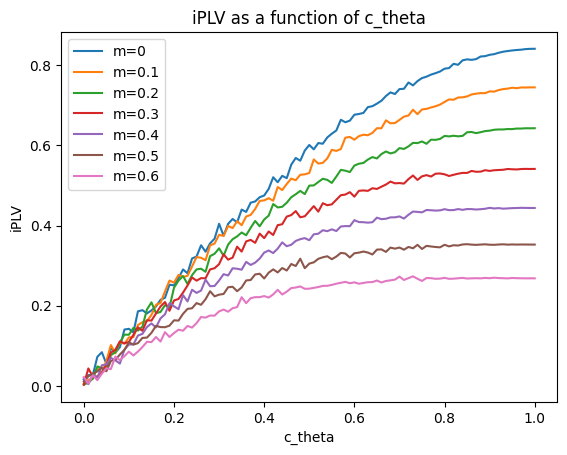

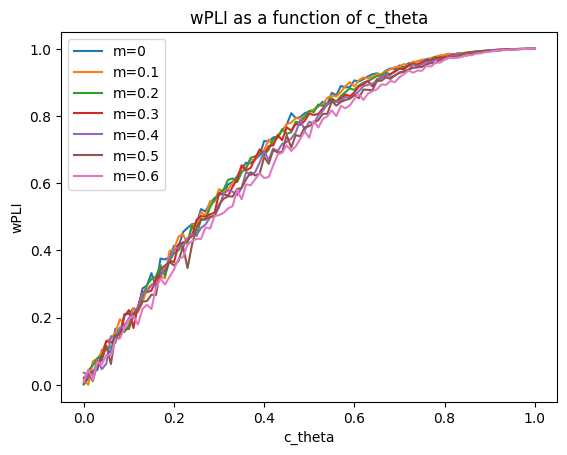

In [ ]:
#OPTION 2: Noisy synchrony curves, processing time approx. 10min

plv_list, iplv_list, wpli_list = plv_iplv_wpli(c_A_list, c_theta_list, m_list, phase_shift_list)

#plottting noisy synchrony curves. plt.show() needed since plotting method lacks it
plot_selected_synchrony(plv_list, m_list, c_theta_list, 'c_theta', 'PLV')
plt.show()
plot_selected_synchrony(iplv_list, m_list, c_theta_list, 'c_theta','iPLV')
plt.show()
plot_selected_synchrony(wpli_list, m_list, c_theta_list,'c_theta', 'wPLI')
plt.show()

When looking on the graphs one can easily observe follwing items how phase mixing parameter affects PLV, iPLV, and wPLI in different ways:

* In the PLV graph we can see that the higher the signals inter-mixing parameter m is the higher the PLV value is. 
* The opposite behaviour can be seen in the iPLV graph i.e. the higher m, the lower iPLV value.
* PLV values are in general higher than iPLV values, because iPLV values only take into account imaginary part of the cPLV values whereas PLV take into account both the real and imaginary part of cPLV values.
* wPLI on the other hand is not that sensitive to the m value when describing synchrony between two mixed signals.
* When c_theta increases, the synchrony values increases for all metrics. 

## 3.2. Mean phase difference affect on synchrony

How will the PLV, iPLV, and wPLI behave then for different mean phase differences across two signals, <span style="color:#85C1E9">phase_shift</span>, and different signals inter-mixing parameters <span style="color:#85C1E9">m</span>? For that we set the amplitude mixing parameter <span style="color:#85C1E9">c_A</span> and phase mixing paramter <span style="color:#85C1E9">c_theta</span> to 1 and 0.4 respectively.

In [45]:
c_A_list = [1]
c_theta_list = [0.4]
m_list = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6]
steps = 100
phase_shift_list = np.linspace(-np.pi, np.pi, steps)

For the same reasons as discussed in previous section 3.1. we will handle the noisy synchrony curves of PLV, iPLV, wPLI values for different <span style="color:#85C1E9">phase_shift</span> and same <span style="color:#85C1E9">c_theta</span> by utilizing <span style="color:#F9E79F">mean_plv_iplv_wpli</span> with 10 <span style="color:#85C1E9">iterations</span>. 

Once again the processing is on the order of approx. 1.5h (Option 1), so now you have time for some other activities. If you are too eager to wait for the plots and do not mind the noisy curves, you can skip the next code block and go to the following code block (Option 2) to see how the synchrony results looks like (processing time approx. 10min). If you are even more eager, you can go to the third code block (Option 3) below and just open the plots that was generated with 10 <span style="color:#85C1E9">iterations</span>. 

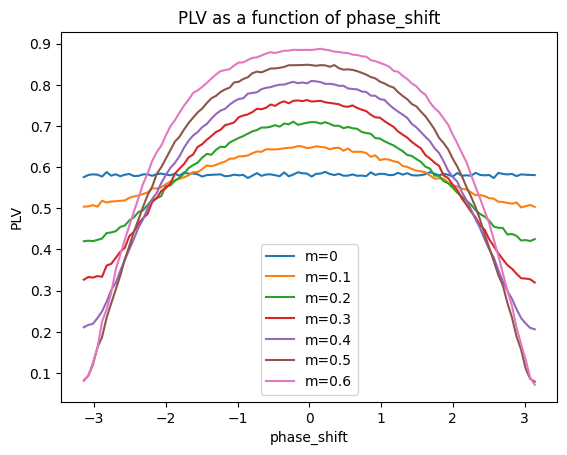

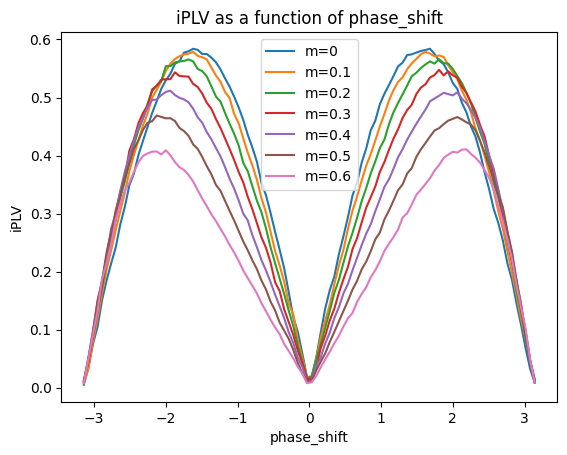

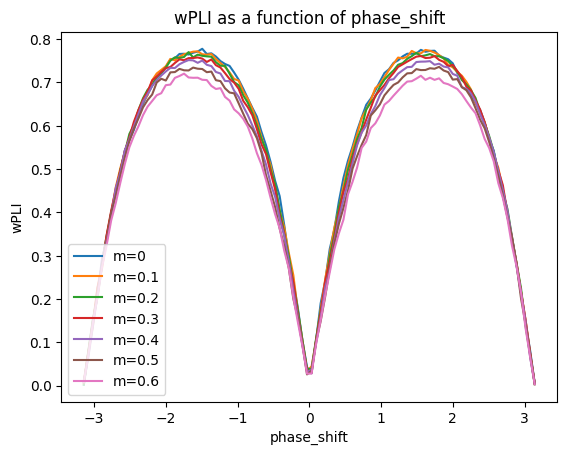

In [46]:
#OPTION 1: Less noisy synchrony curves, processing time approx. 1.5h

iterations = 10
mean_plvs, mean_iplvs, mean_wplis = mean_plv_iplv_wpli(c_A_list, c_theta_list, m_list, phase_shift_list, iterations)

#plottting less noisy synchrony curves. saving plots. plt.show() needed since plotting method lacks it
plot_selected_synchrony(mean_plvs, m_list, phase_shift_list, 'phase_shift', 'PLV')
plt.savefig('demo_files/phase_shift_vs_plv.png')
plt.show()

plot_selected_synchrony(mean_iplvs, m_list, phase_shift_list, 'phase_shift','iPLV')
plt.savefig('demo_files/phase_shift_vs_iplv.png')
plt.show()

plot_selected_synchrony(mean_wplis, m_list, phase_shift_list,'phase_shift', 'wPLI')
plt.savefig('demo_files/phase_shift_vs_wpli.png')
plt.show()

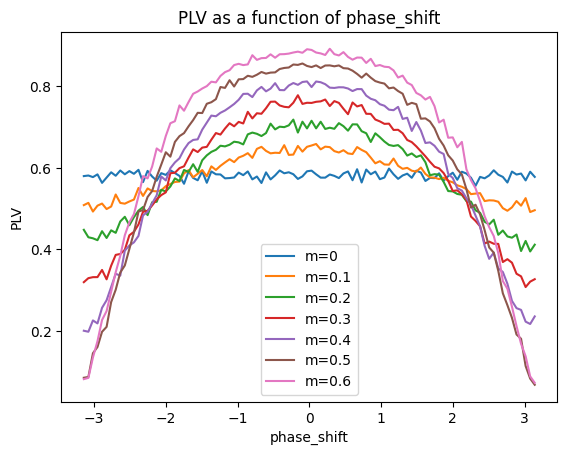

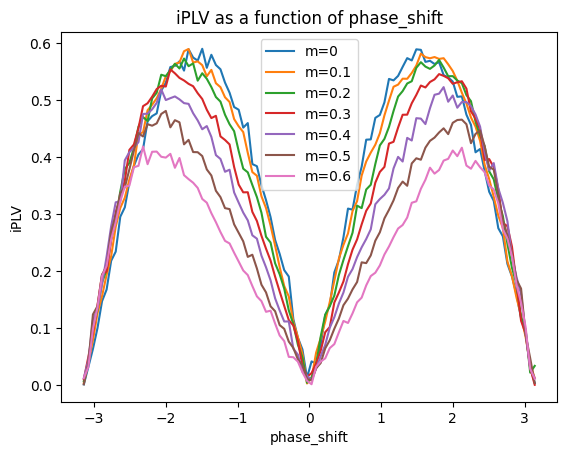

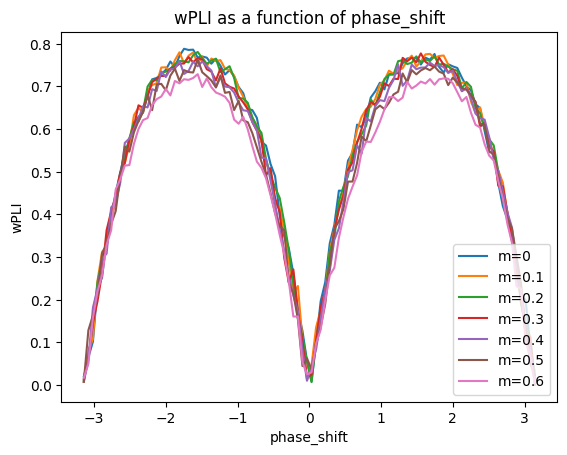

In [ ]:
#OPTION 2: Noisy synchrony curves, processing time approx. 10min

plv_list, iplv_list, wpli_list = plv_iplv_wpli(c_A_list, c_theta_list, m_list, phase_shift_list)

#plottting noisy synchrony curves. plt.show() needed since plotting method lacks it
plot_selected_synchrony(plv_list, m_list, phase_shift_list, 'phase_shift','PLV')
plt.show()
plot_selected_synchrony(iplv_list, m_list, phase_shift_list, 'phase_shift',  'iPLV')
plt.show()
plot_selected_synchrony(wpli_list, m_list, phase_shift_list, 'phase_shift', 'wPLI')
plt.show()

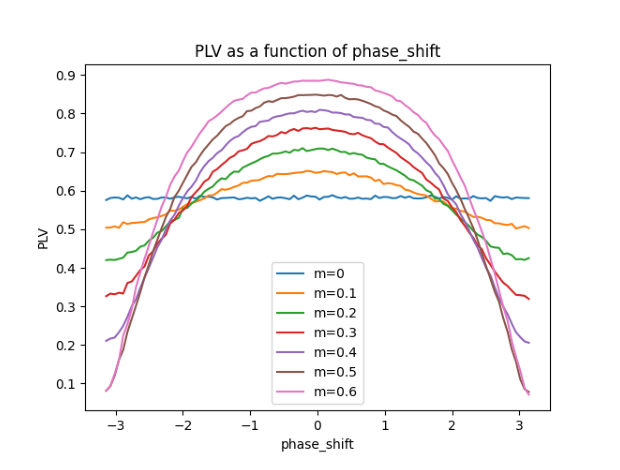

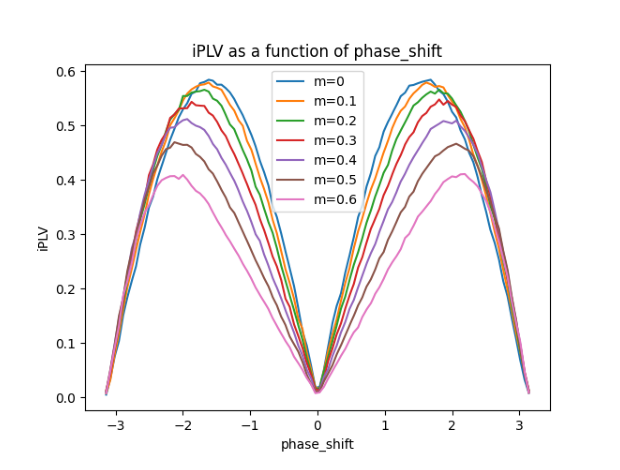

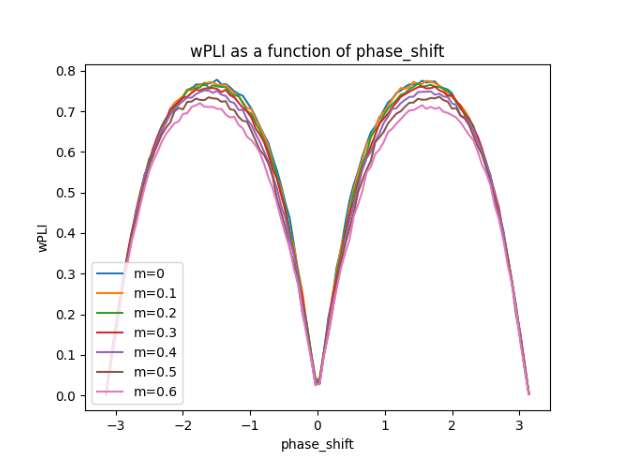

In [47]:
#OPTION 3: Show less noisy synchrony curves

image_path_plv = 'demo_files/phase_shift_vs_plv.png'
image_plv = mpimg.imread(image_path_plv)
plt.imshow(image_plv)
plt.axis('off')
plt.tight_layout() 
plt.show()

image_path_plv = 'demo_files/phase_shift_vs_iplv.png'
image_plv = mpimg.imread(image_path_plv)
plt.imshow(image_plv)
plt.axis('off') 
plt.tight_layout()
plt.show()

image_path_plv = 'demo_files/phase_shift_vs_wpli.png'
image_plv = mpimg.imread(image_path_plv)
plt.imshow(image_plv)
plt.axis('off') 
plt.tight_layout()
plt.show()

When observing the graphs above one can notice mean phase difference affect PLV, iPLV, and wPLI: 

* In the PLV graph largest values are obtained with phase_shift around 0. The higher the signal inter-mixing parameter m, the higher the PLV value.
* On the other hand, phase_shift values around 0 will give low iPLV values. Opposite to the PLV graph, the higher the signal inter-mixing parameter m the lower iPLV value.
* The wPLI graph reminds of the iPLV graph, but wPLI values are less affected by the degree of signal inter-mixing paramter m.